In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

DATA_DIR = Path("../data/raw")
print("Setup complete")

Setup complete


In [3]:
from collections import defaultdict

data_summary = defaultdict(lambda: defaultdict(int))

for label in ["real", "ai_generated"]:
    label_path = DATA_DIR / label
    
    for category in os.listdir(label_path):
        category_path = label_path / category
        
        if os.path.isdir(category_path):
            num_images = len(os.listdir(category_path))
            data_summary[label][category] = num_images

# Convert to DataFrame
df_counts = pd.DataFrame(data_summary).fillna(0).astype(int)

# Add totals
df_counts.loc["TOTAL"] = df_counts.sum()

df_counts

,real,ai_generated
animals,148,50
city,150,50
food,150,50
nature,150,50
people,147,50
TOTAL,745,250


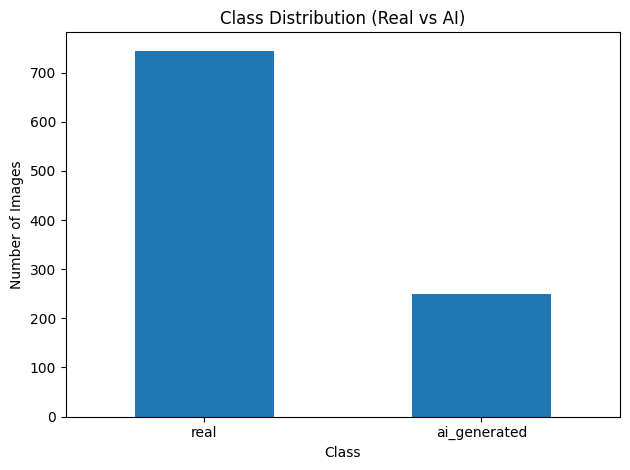

In [ ]:
class_counts = df_counts.loc["TOTAL"]

plt.figure()
class_counts.plot(kind="bar")

plt.title("Class Distribution (Real vs AI)")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

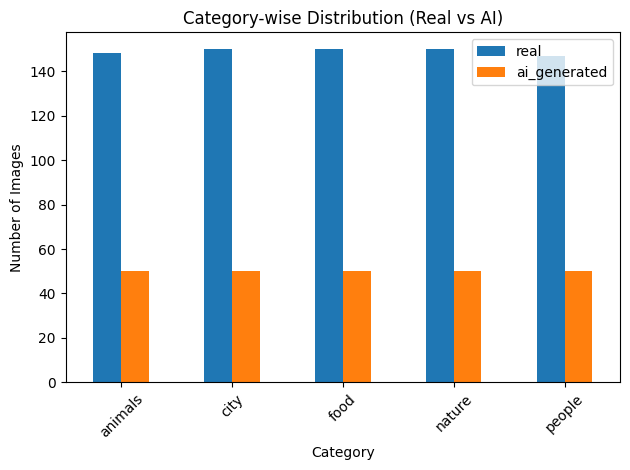

In [5]:
df_counts.drop("TOTAL").plot(kind="bar")

plt.title("Category-wise Distribution (Real vs AI)")
plt.xlabel("Category")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

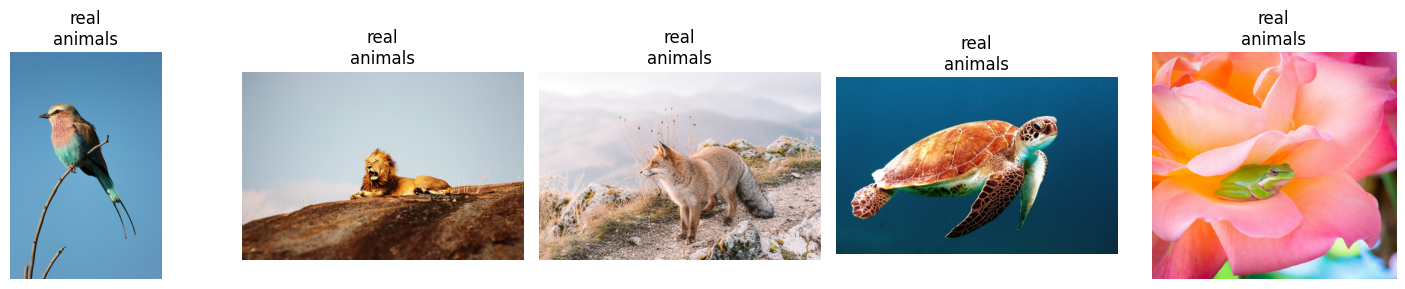

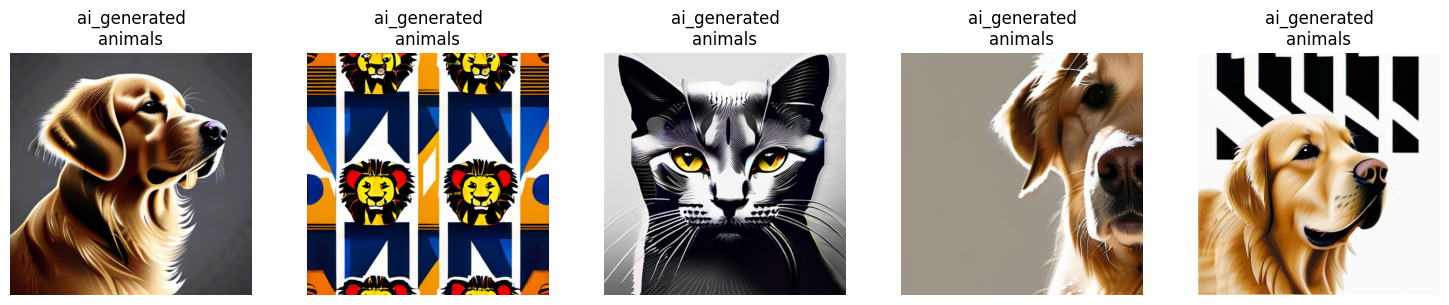

In [6]:
import random

def show_samples(label, category, n=5):
    path = DATA_DIR / label / category
    images = os.listdir(path)
    
    samples = random.sample(images, n)
    
    plt.figure(figsize=(15, 3))
    
    for i, img_name in enumerate(samples):
        img_path = path / img_name
        img = Image.open(img_path)
        
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f"{label}\n{category}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()


# Try samples
show_samples("real", "animals")
show_samples("ai_generated", "animals")

In [ ]:
sizes = []

for label in ["real", "ai_generated"]:
    label_path = DATA_DIR / label
    
    for category in os.listdir(label_path):
        category_path = label_path / category
        
        for img_name in os.listdir(category_path):
            img_path = category_path / img_name
            
            try:
                img = Image.open(img_path)
                sizes.append(img.size)  # (width, height)
            except:
                continue

df_sizes = pd.DataFrame(sizes, columns=["width", "height"])

df_sizes.describe()

,width,height
count,995.000000,995.000000
mean,937.801005,974.472362
std,246.131152,459.864530
min,512.000000,375.000000
25%,768.000000,512.000000
50%,1080.000000,720.000000
75%,1080.000000,1618.000000
max,1080.000000,1922.000000


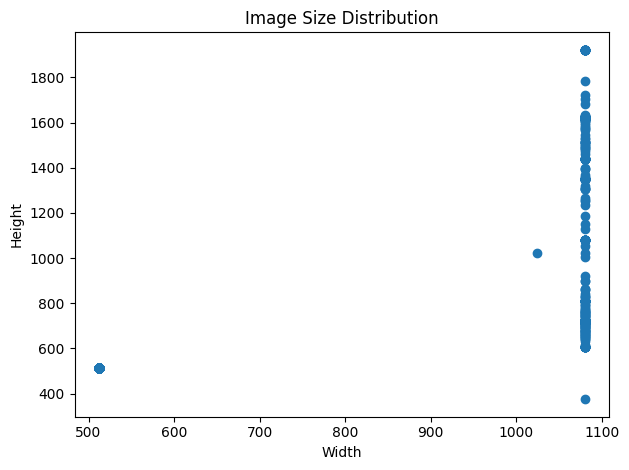

In [8]:
plt.figure()
plt.scatter(df_sizes["width"], df_sizes["height"])

plt.title("Image Size Distribution")
plt.xlabel("Width")
plt.ylabel("Height")

plt.tight_layout()
plt.show()

In [9]:
corrupted = []

for label in ["real", "ai_generated"]:
    label_path = DATA_DIR / label
    
    for category in os.listdir(label_path):
        category_path = label_path / category
        
        for img_name in os.listdir(category_path):
            img_path = category_path / img_name
            
            try:
                img = Image.open(img_path)
                img.verify()  # verify integrity
            except:
                corrupted.append(str(img_path))

len(corrupted)

0

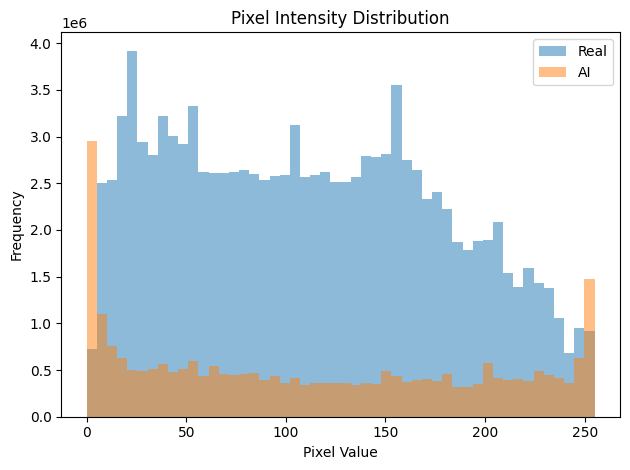

In [10]:
def get_pixel_data(label, max_images=100):
    pixels = []
    count = 0
    
    for category in os.listdir(DATA_DIR / label):
        category_path = DATA_DIR / label / category
        
        for img_name in os.listdir(category_path):
            if count >= max_images:
                return np.array(pixels)
            
            img_path = category_path / img_name
            
            try:
                img = Image.open(img_path).convert("L")  # grayscale
                pixels.extend(np.array(img).flatten())
                count += 1
            except:
                continue
    
    return np.array(pixels)


real_pixels = get_pixel_data("real")
ai_pixels = get_pixel_data("ai_generated")


plt.figure()
plt.hist(real_pixels, bins=50, alpha=0.5, label="Real")
plt.hist(ai_pixels, bins=50, alpha=0.5, label="AI")

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.legend()
plt.tight_layout()
plt.show()

In [11]:
eda_summary = {
    "Total Images": int(df_counts.loc["TOTAL"].sum()),
    "Real Images": int(df_counts.loc["TOTAL"]["real"]),
    "AI Images": int(df_counts.loc["TOTAL"]["ai_generated"]),
    "Class Imbalance Ratio (Real:AI)": round(
        df_counts.loc["TOTAL"]["real"] / df_counts.loc["TOTAL"]["ai_generated"], 2
    ),
    "Min Width": int(df_sizes["width"].min()),
    "Max Width": int(df_sizes["width"].max()),
    "Min Height": int(df_sizes["height"].min()),
    "Max Height": int(df_sizes["height"].max()),
    "Corrupted Images": len(corrupted)
}

eda_summary

{'Total Images': 995,
 'Real Images': 745,
 'AI Images': 250,
 'Class Imbalance Ratio (Real:AI)': np.float64(2.98),
 'Min Width': 512,
 'Max Width': 1080,
 'Min Height': 375,
 'Max Height': 1922,
 'Corrupted Images': 0}